In [1]:
from learn_to_infer import Worker
from task import SwitchingBandit
import pandas as pd
import torch
import numpy as np

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
from task import false_positive_rate, gaussian_false_positive_rate, volatility_distribution, false_positive_rate_distribution, mu_distribution


In [10]:
np.quantile(vols, np.linspace(0, 1, 5))

array([0.10003385, 0.12857766, 0.16735115, 0.23351389, 0.4999144 ])

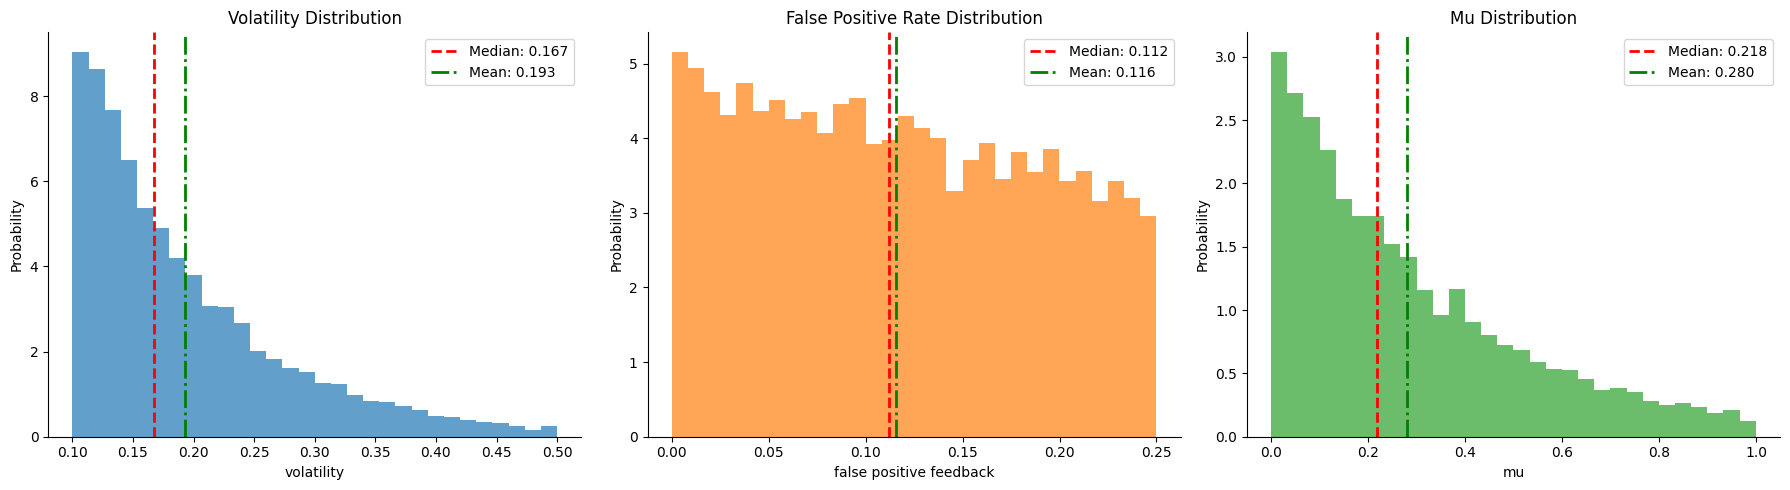

In [2]:
nb_samples = 10000
vols = [volatility_distribution(lambda_param=10) for _ in range(nb_samples)]
false_positives = np.array([false_positive_rate_distribution(lambda_param=2) for _ in range(nb_samples)])
mus = np.array([mu_distribution(lambda_param=3) for _ in range(nb_samples)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Volatility
axes[0].hist(vols, bins=30, density=True, alpha=0.7, color='C0')
median_vol = np.median(vols)
mean_vol = np.mean(vols)
axes[0].axvline(median_vol, color='red', linestyle='--', linewidth=2, label=f'Median: {median_vol:.3f}')
axes[0].axvline(mean_vol, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_vol:.3f}')
axes[0].set_xlabel('volatility')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].set_title("Volatility Distribution")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# False positive feedback
axes[1].hist(false_positives, bins=30, density=True, alpha=0.7, color='C1')
median_fp = np.median(false_positives)
mean_fp = np.mean(false_positives)
axes[1].axvline(median_fp, color='red', linestyle='--', linewidth=2, label=f'Median: {median_fp:.3f}')
axes[1].axvline(mean_fp, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_fp:.3f}')
axes[1].set_xlabel('false positive feedback')
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].set_title("False Positive Rate Distribution")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Mu
axes[2].hist(mus, bins=30, density=True, alpha=0.7, color='C2')
median_mu = np.median(mus)
mean_mu = np.mean(mus)
axes[2].axvline(median_mu, color='red', linestyle='--', linewidth=2, label=f'Median: {median_mu:.3f}')
axes[2].axvline(mean_mu, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_mu:.3f}')
axes[2].set_xlabel('mu')
axes[2].set_ylabel('Probability')
axes[2].legend()
axes[2].set_title("Mu Distribution")
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/bandit_parameter_distributions.pdf')
plt.show()


In [13]:
nb_samples = 10000

mus = np.zeros(nb_samples)
sigmas = np.zeros(nb_samples)
false_positive_feedbacks = np.zeros(nb_samples)
for i in range(nb_samples):
    stimulus_range, p_gen, mus[i], sigmas[i], false_positive_feedbacks[i] = gaussian_false_positive_rate(return_stimulus_range=True)

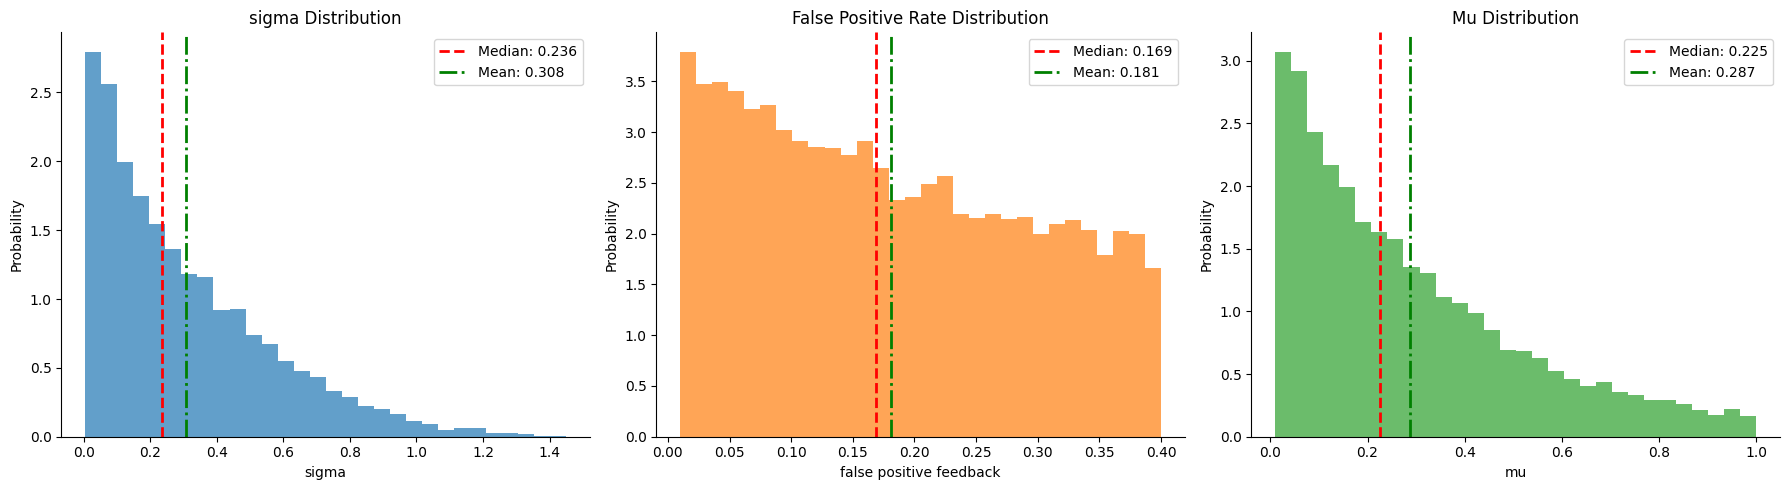

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Volatility
axes[0].hist(sigmas, bins=30, density=True, alpha=0.7, color='C0')
median_vol = np.median(sigmas)
mean_vol = np.mean(sigmas)
axes[0].axvline(median_vol, color='red', linestyle='--', linewidth=2, label=f'Median: {median_vol:.3f}')
axes[0].axvline(mean_vol, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_vol:.3f}')
axes[0].set_xlabel('sigma')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].set_title("sigma Distribution")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# False positive feedback
axes[1].hist(false_positive_feedbacks, bins=30, density=True, alpha=0.7, color='C1')
median_fp = np.median(false_positive_feedbacks)
mean_fp = np.mean(false_positive_feedbacks)
axes[1].axvline(median_fp, color='red', linestyle='--', linewidth=2, label=f'Median: {median_fp:.3f}')
axes[1].axvline(mean_fp, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_fp:.3f}')
axes[1].set_xlabel('false positive feedback')
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].set_title("False Positive Rate Distribution")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Mu
axes[2].hist(mus, bins=30, density=True, alpha=0.7, color='C2')
median_mu = np.median(mus)
mean_mu = np.mean(mus)
axes[2].axvline(median_mu, color='red', linestyle='--', linewidth=2, label=f'Median: {median_mu:.3f}')
axes[2].axvline(mean_mu, color='green', linestyle='-.', linewidth=2, label=f'Mean: {mean_mu:.3f}')
axes[2].set_xlabel('mu')
axes[2].set_ylabel('Probability')
axes[2].legend()
axes[2].set_title("Mu Distribution")
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/bandit_parameter_distributions.pdf')
plt.show()


Fitted exponential rate (lambda): 3.2513
Fitted scale (1/lambda): 0.3076


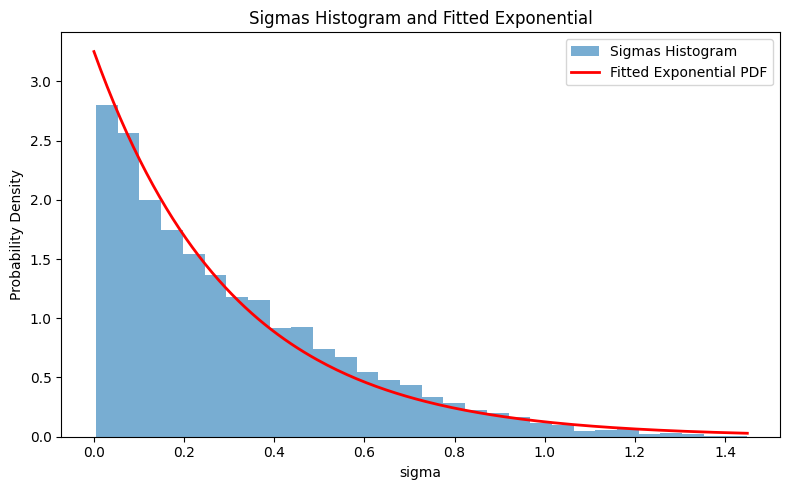

In [15]:
from scipy.stats import expon
import matplotlib.pyplot as plt
import numpy as np

# Fit an exponential distribution to the sigmas array
loc, scale = expon.fit(sigmas, floc=0)  # Set floc=0 to force the distribution to start at 0

print(f"Fitted exponential rate (lambda): {1/scale:.4f}")
print(f"Fitted scale (1/lambda): {scale:.4f}")

# Plot histogram and fitted exponential
fig, ax = plt.subplots(figsize=(8, 5))
count, bins, _ = ax.hist(sigmas, bins=30, density=True, alpha=0.6, color='C0', label='Sigmas Histogram')

# Plot fitted exponential PDF
x = np.linspace(0, np.max(sigmas), 200)
pdf_fitted = expon.pdf(x, loc, scale)
ax.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted Exponential PDF')

# Add legend and labels
ax.set_xlabel('sigma')
ax.set_ylabel('Probability Density')
ax.set_title('Sigmas Histogram and Fitted Exponential')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
sigmas.max()

1.4494878387331143

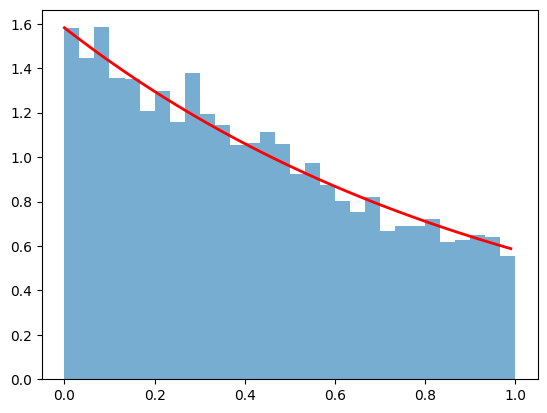

In [6]:
from task import truncated_exponential_logpdf, sample_truncated_exponential
samples = sample_truncated_exponential(size=10000, lambda_param=1.0, ub=1.0)
logpdf = truncated_exponential_logpdf(np.arange(0, 1, 0.01), lambda_param=1.0, ub=1.0)
plt.hist(samples, bins=30, density=True, alpha=0.6, color='C0', label='Sigmas Histogram')
plt.plot(np.arange(0, 1, 0.01), np.exp(logpdf), 'r-', lw=2, label='Fitted Exponential PDF')
plt.show()

ValueError: too many values to unpack (expected 4)

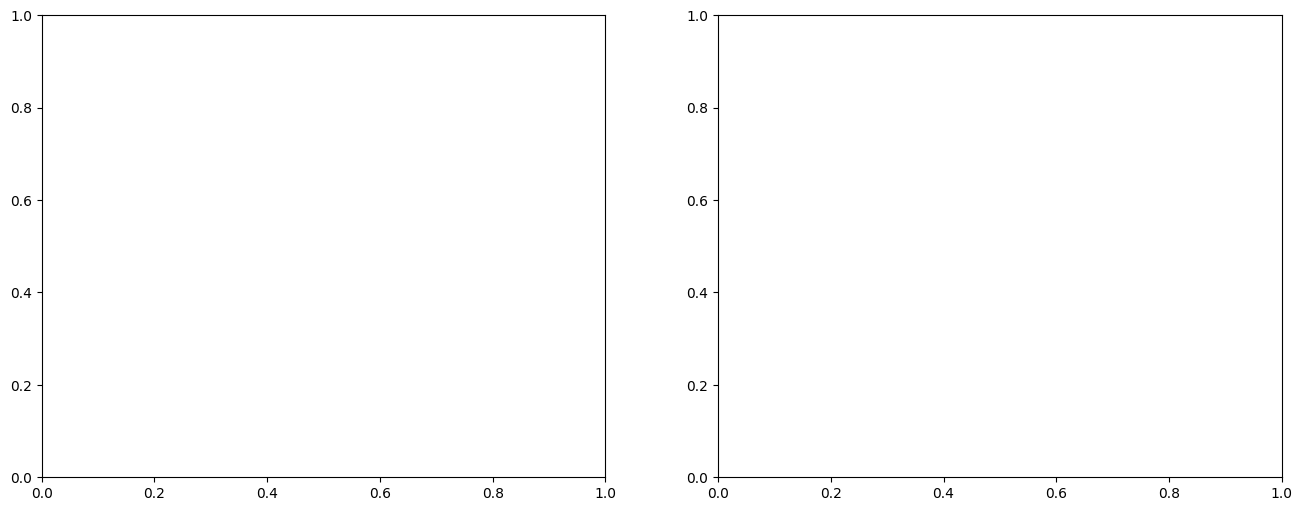

In [7]:
# Create a range of llrmax values from 0.8 to 7
# Create color map
colors = plt.cm.viridis(np.linspace(0, 1, 20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
ax1, ax2 = axes

false_positives = []
mu1 = 0.1
mu2 = 0.4

for i, ff in enumerate(np.linspace(0.1, 0.4, 20)):  # use the same grid as llrmax_values for comparison
    s, p, mu, _ = gaussian_false_positive_rate(mu=mu1, false_positive_feedback=ff, return_stimulus_range=True)
    ax1.plot(s, p, color=colors[i], alpha=0.7, label=f'ff={ff:.1f}')
# Add vertical dashed line for mu
ax1.axvline(mu1, color='black', linestyle='--', linewidth=1, label='mu')
ax1.axvline(0, color='gray', linestyle='--', linewidth=1, label='mu')

ax1.set_title('Gaussian False Positive Rate')

for i, ff in enumerate(np.linspace(0.1, 0.4, 20)):  # use the same grid as llrmax_values for comparison
    s, p, mu, _ = gaussian_false_positive_rate(mu=mu2, false_positive_feedback=ff, return_stimulus_range=True)
    ax2.plot(s, p, color=colors[i], alpha=0.7, label=f'ff={ff:.1f}')
# Add vertical dashed line for mu
ax2.axvline(mu2, color='black', linestyle='--', linewidth=1, label='mu')
ax2.axvline(0, color='gray', linestyle='--', linewidth=1, label='mu')

ax2.set_title('Gaussian False Positive Rate')

for ax in axes:
    ax.set_ylabel('Probability')
    ax.set_xlabel('Stimulus level')

# Colorbar is hidden, nothing is drawn here
plt.tight_layout()
plt.savefig('figures/bandit_false_feedback_distributions.pdf')
plt.show()

In [ ]:
np.sum(s *s * p) - np.sum(s * p) ** 2

0.2807015090522793

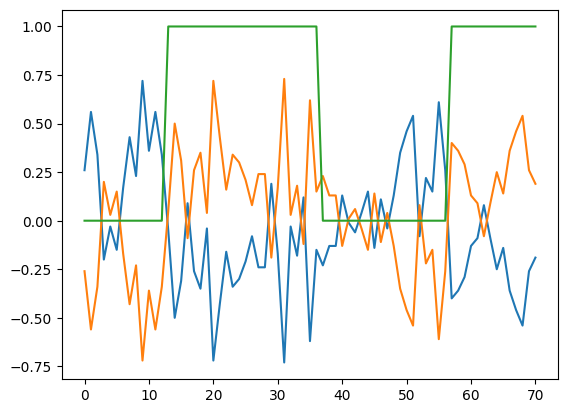

In [2]:
np.random.seed(45)
task = SwitchingBandit(n_trials=71)
correct_arms = np.tile(np.array([0] * 13 + [1] * 24 + [0] * 20 + [1] * 14)[None], (2, 1)) 
task._generate_task_schedule(mus=np.ones(100) * 0.2, nus=np.ones(100) * 0.05, nb_tasks=2, correct_arms=correct_arms)
i = 1
plt.figure()
plt.plot(task.feedback_arm0[i])
plt.plot(task.feedback_arm1[i])
plt.plot(task.correct_arms[i])
#plt.savefig('figures/task.pdf')

In [4]:
from learn_to_infer import Worker
np.random.seed(45)
self = Worker(
    SwitchingBandit(n_trials=71),
    "results/source/saved_models",
    "banditGRU_newinit_val_0_beta2_id{0}".format(1),
)

self.load_model(nb_episodes=50000)

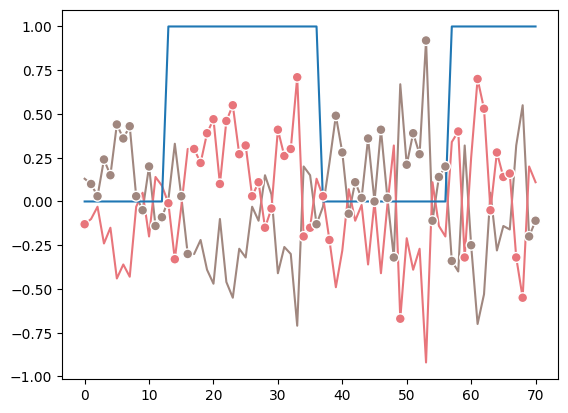

In [46]:
np.random.seed(32)
self.env.reset(mus=np.ones(100) * 0.2, nus=np.ones(100) * 0.05, nb_tasks=2, correct_arms=correct_arms)
result = self.evaluate()

i = 1
plt.figure()
plt.plot(self.env.feedback_arm0[i], color="#A0877F")
plt.plot(self.env.feedback_arm1[i], color="#E8757B")
# Determine which arm was chosen each trial (assuming 'actions' in results)
colors = np.where(result['actions'][i] == 0, "#A0877F", "#E8757B")
# Add white outcircle behind points
plt.scatter(
    np.arange(self.env.n_trials), result['rewards'][i],
    s=50, edgecolors='white', linewidth=1, color=colors, zorder=3
)
plt.plot(self.env.correct_arms[i])
plt.savefig('figures/task_w_feedback.pdf')

In [38]:
pwd

'/Users/csmfindling/Documents/Postdoc-Geneva/neuralHMMs/code/bandit'

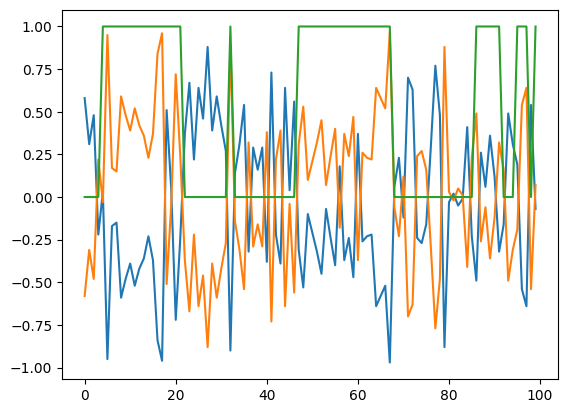

In [17]:
i = 1
plt.figure()
plt.plot(task.feedback_arm0[i])
plt.plot(task.feedback_arm1[i])
plt.plot(task.correct_arms[i])
plt.savefig('figures/task.pdf')